In [1]:
import FFTW
using BenchmarkTools
using ProgressBars
include("fft.jl")

# Now you can use:
# FFTW.fft() for the FFTW version
# fft() for your custom version (from fft.jl)

ifftnshift (generic function with 1 method)

In [28]:
len = 2^8
a_1d = rand(len) + 1im*rand(len) 
a_2d = rand(len, len) + 1im*rand(len, len) 
@assert FFTW.fft(a_1d) ≈ fft(a_1d)
@assert FFTW.fft(a_2d) ≈ fft(a_2d)
@assert FFTW.ifft(a_1d) ≈ ifft(a_1d)    
@assert FFTW.ifft(a_2d) ≈ ifft(a_2d)
@assert FFTW.fftshift(a_1d) ≈ fftshift(a_1d)
@assert FFTW.fftshift(a_2d) ≈ fftshift(a_2d)


isapprox

isapprox (generic function with 22 methods)

In [ ]:
Functions = [FFTW.fft, fft, FFTW.ifft, ifft, FFTW.fftshift, fftshift]
Function_names = ["FFTW.fft", "Custom fft", "FFTW.ifft", "Custom ifft", "FFTW.fftshift", "Custom fftshift"]


function benchmark_dictionary(Function_names, Functions)
    benchmark_dict = Dict()

    # For each function, store function reference and benchmark data
    for (name, func) in zip(Function_names, Functions)
        benchmark_dict[name] = Dict(
            "function" => func,
            "1D" => Dict(),
            "2D" => Dict()
        )
    end
    return benchmark_dict
end

# Function to add benchmark results
function add_benchmark_results!(dict, func_name::String, dimension::String, time::AbstractFloat, allocations::Int, N::Int)
    # dict[func_name][dimension][]["time"] = 
    # dict[func_name][dimension]["allocations"] = allocations
    dict[func_name][dimension][N] = (time, allocations)
end

function fourier_benchmark(benchmark_dict, sizes::Vector{Int}, Function_names::Vector{String}, Functions::Vector{Function})
    for N in ProgressBar(sizes)
        a_1d = rand(N) + 1im*rand(N) 
        a_2d = rand(N, N) + 1im*rand(N, N) 
        Threads.@threads for (name, func) in zip(Function_names, Functions)
            # 1D benchmark
            time_1d = @belapsed $func($a_1d)
            allocations_1d = @allocated func(a_1d)
            add_benchmark_results!(benchmark_dict, name, "1D", time_1d, allocations_1d, N)

            # 2D benchmark
            time_2d = @belapsed $func($a_2d)
            allocations_2d = @allocated func(a_2d)
            add_benchmark_results!(benchmark_dict, name, "2D", time_2d, allocations_2d, N)
        end
    end
    return benchmark_dict
end



fourier_benchmark (generic function with 1 method)

In [ ]:
using DataFrames

In [29]:
sizes = [2^i for i in 2:13]  # Sizes from 2^4 to 2^10
Functions = [FFTW.fft, fft, FFTW.ifft, ifft]
Function_names = ["FFTW.fft", "Custom fft", "FFTW.ifft", "Custom ifft"]

benchmark_dict = benchmark_dictionary(Function_names, Functions)
results_dict = fourier_benchmark(benchmark_dict, sizes, Function_names, Functions)
println("Benchmarks completed!")


0.0%┣                                               ┫ 0/12 [00:00<00:00, -0s/it]
8.3%┣███▋                                       ┫ 1/12 [00:23<Inf:Inf, InfGs/it]
16.7%┣███████▊                                      ┫ 2/12 [00:48<07:57, 48s/it]
25.0%┣███████████▌                                  ┫ 3/12 [01:19<05:54, 39s/it]
33.3%┣███████████████▍                              ┫ 4/12 [01:49<04:52, 36s/it]
41.7%┣███████████████████▏                          ┫ 5/12 [02:29<04:20, 37s/it]
50.0%┣███████████████████████                       ┫ 6/12 [03:15<03:53, 39s/it]
58.3%┣██████████████████████████▉                   ┫ 7/12 [04:09<03:28, 42s/it]
66.7%┣██████████████████████████████▊               ┫ 8/12 [05:09<02:57, 44s/it]
75.0%┣██████████████████████████████████▌           ┫ 9/12 [06:14<02:20, 47s/it]
83.3%┣█████████████████████████████████████▌       ┫ 10/12 [07:23<01:39, 49s/it]
91.7%┣█████████████████████████████████████████▎   ┫ 11/12 [08:57<00:54, 54s/it]


Benchmarks completed!


100.0%┣████████████████████████████████████████████┫ 12/12 [11:10<00:00, 61s/it]
100.0%┣████████████████████████████████████████████┫ 12/12 [11:10<00:00, 61s/it]


In [16]:
results_dict["FFTW.fft"]["1D"][sizes[end]]  # Example to access results

(4.927666666666667e-6, 8528)

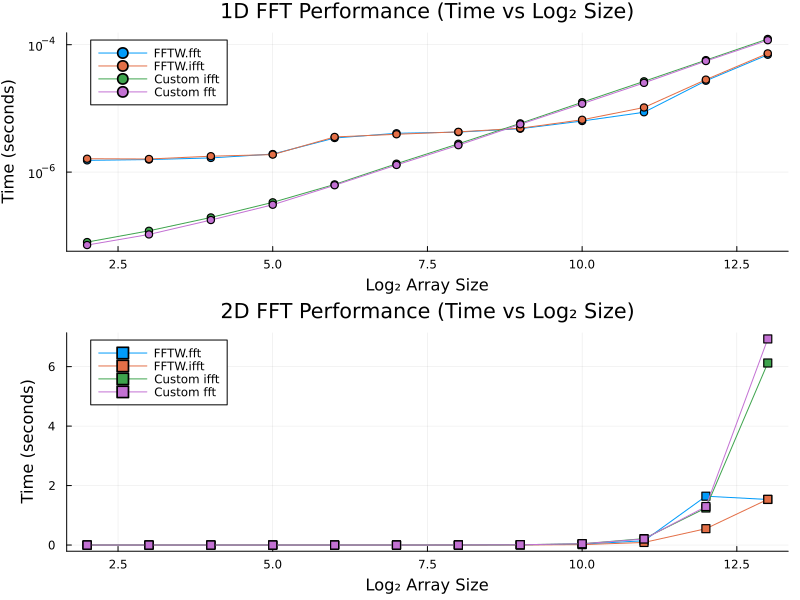

In [91]:
using Plots


# Create separate plots for 1D and 2D
p1 = plot(title="1D FFT Performance (Time vs Log₂ Size)",
          xlabel="Log₂ Array Size", 
          ylabel="Time (seconds)",
          yscale=:log10,
          legend=:topleft)
        #   xlims=(log2(sizes[1]), log2(sizes[end])))

          
p2 = plot(title="2D FFT Performance (Time vs Log₂ Size)",
          xlabel="Log₂ Array Size", 
          ylabel="Time (seconds)",
          # yscale=:log10,
          legend=:topleft)
        #   xlims=(log2(sizes[1]), log2(sizes[end])))

log_sizes = log2.(sizes)
for (name, func_dict) in results_dict
    # println(func_dict)
    if name == "FFTW.fftshift" || name == "Custom fftshift"
        continue  # Skip fftshift functions
    end

    times_1d = [func_dict["1D"][size][1] for size in sizes]
    times_2d = [func_dict["2D"][size][1] for size in sizes]

    # Plot 1D results
    plot!(p1, log_sizes, times_1d, label=name, marker=:circle)

    # Plot 2D results
    plot!(p2, log_sizes, times_2d, label=name, marker=:square)
end
plot(p1, p2, layout=(2, 1), size=(800, 600))

k range:-643.0840161898673 to 642.4560044553068


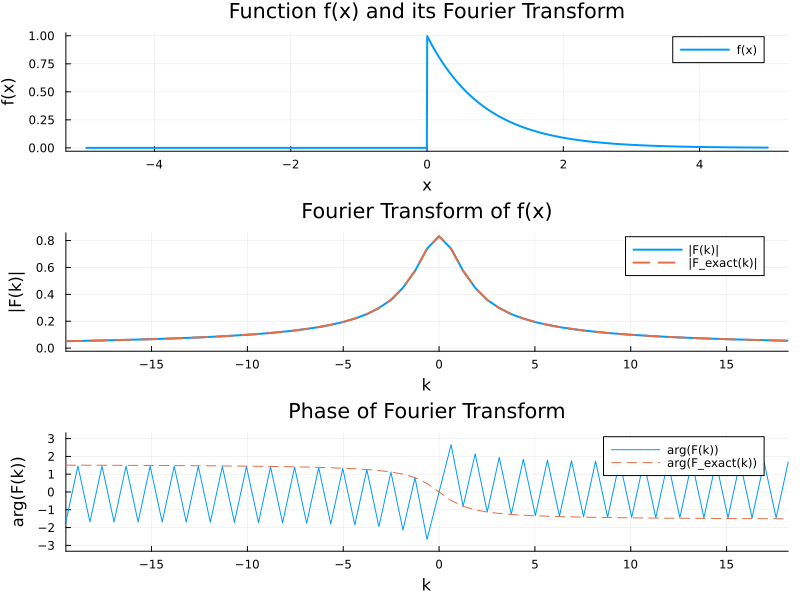

In [89]:
N, L = 2048, 10.0        # points, window length
x = range(-L/2, L/2, length=N)
dx = x[2]-x[1]

# parameters and function
a = 1.2
f = @. exp(-a*x) * (x > 0)  # Element-wise multiplication for array

# numerical FT (unitary angular-frequency convention)
F = FFTW.fftshift(FFTW.fft(f)) * dx
k = FFTW.fftshift(FFTW.fftfreq(N, 1/dx))  # angular frequency
k = @. k * 2π  # Convert to angular frequency
  # Convert to angular frequency
println("k range:", k[1], " to ", k[end])

# analytic FT for comparison
F_exact = @. 1/(a + 1im*k)
window_size = 30  
k_window = [k[N÷2-window_size], k[N÷2+window_size]]

p1 = plot(x, f, label="f(x)", title="Function f(x) and its Fourier Transform",
          xlabel="x", ylabel="f(x)", legend=:topright, linewidth=2)
p2 = plot(k, abs.(F), label="|F(k)|", title="Fourier Transform of f(x)",
            xlabel="k", ylabel="|F(k)|", legend=:topright, linewidth=2)
plot!(p2, k, abs.(F_exact), label="|F_exact(k)|", linestyle=:dash, linewidth=2)
xlims!(p2, k_window...)

p3 = plot(k, angle.(F), label="arg(F(k))", title="Phase of Fourier Transform",
          xlabel="k", ylabel="arg(F(k))", legend=:topright)
plot!(p3, k, angle.(F_exact), label="arg(F_exact(k))", linestyle=:dash)
xlims!(p3, k_window...)

plot(p1, p2, p3, layout=(3, 1), size=(800, 600))

In [67]:
k

-321.54200809493364:0.31400586728020863:321.2280022276534

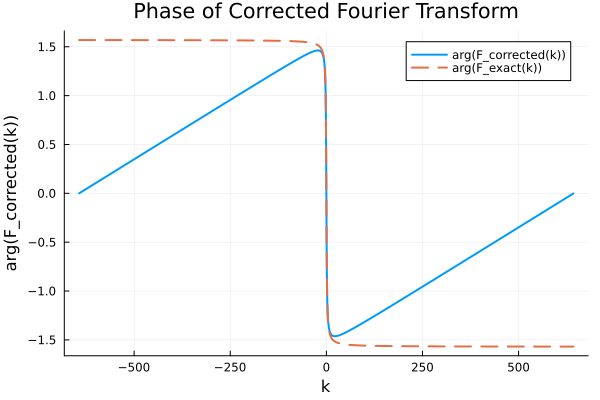

In [90]:
F_corrected = FFTW.fftshift(FFTW.fft(FFTW.ifftshift(f))) * dx
window_size = 200  
k_window = [k[N÷2-window_size], k[N÷2+window_size]]
p1 = plot(k, angle.(F_corrected), label="arg(F_corrected(k))", title="Phase of Corrected Fourier Transform",
          xlabel="k", ylabel="arg(F_corrected(k))", legend=:topright, linewidth=2)
plot!(p1, k, angle.(F_exact), label="arg(F_exact(k))", linestyle=:dash, linewidth=2)
# xlims!(p1, k_window...)
